In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os

parent_path = "C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps"

FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])
rul_df['unit_number'] = rul_df.index + 1 # 엔진 번호(1부터 시작) 추가

train_df

Train path: C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps\train_FD001.txt


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


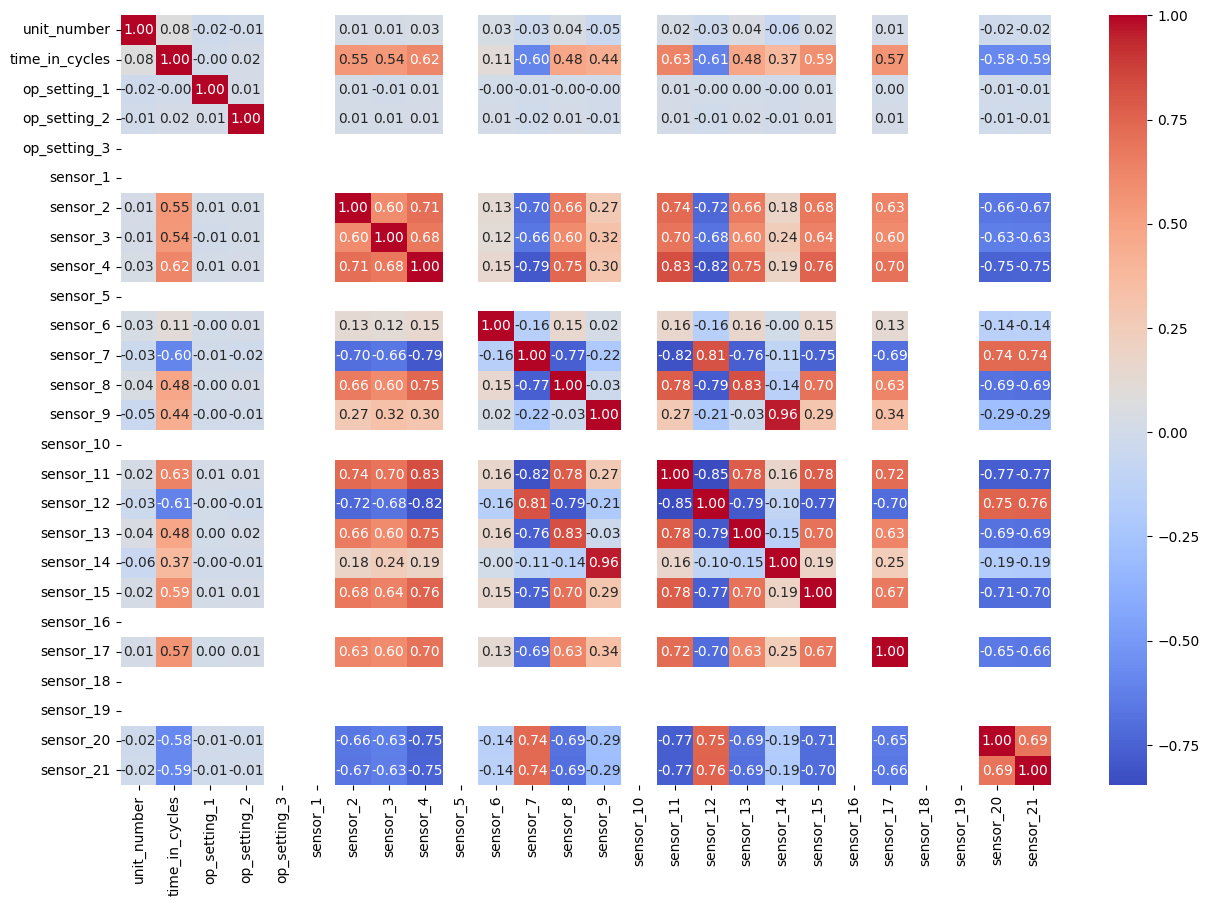

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

#corr = df.corr()

#rul_corr = corr['RUL'].sort_values(ascending=False)

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

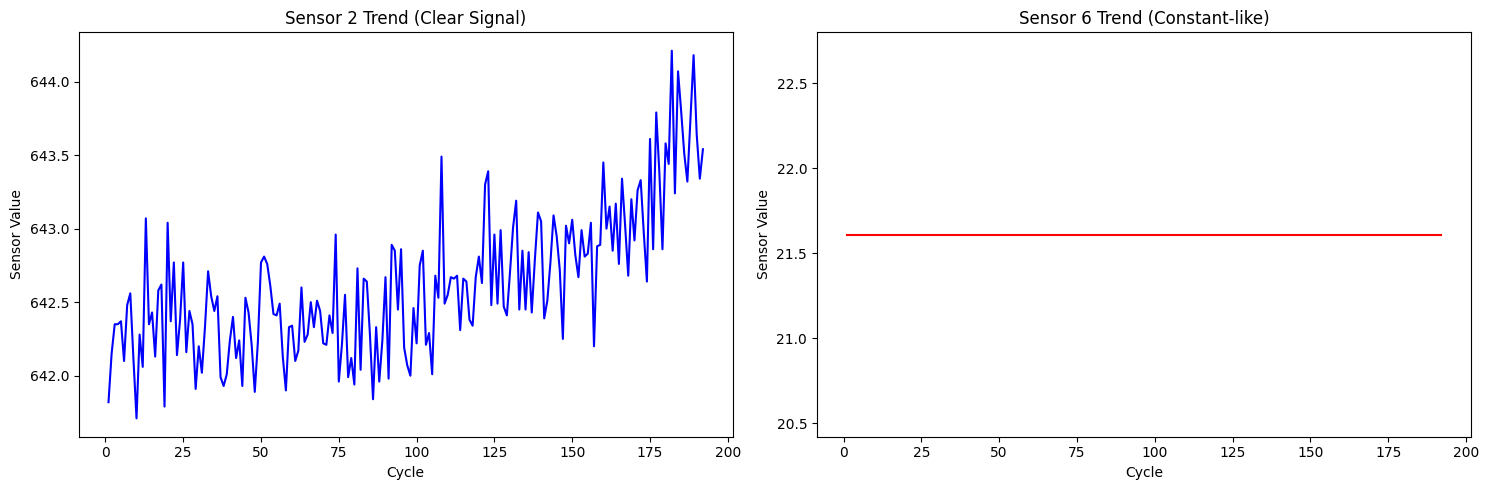

In [12]:
import matplotlib.pyplot as plt

# 1. 1번 엔진 데이터만 추출
engine_1 = train_df[train_df['unit_number'] == 1]

# 2. 시각화 시작
plt.figure(figsize=(15, 5))

# 변화가 뚜렷한 센서 (비교군: 센서 2번)
plt.subplot(1, 2, 1)
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_2'], color='blue')
plt.title('Sensor 2 Trend (Clear Signal)')
plt.xlabel('Cycle')
plt.ylabel('Sensor Value')

# 궁금하신 6번 센서 (확인군)
plt.subplot(1, 2, 2)
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_6'], color='red')
plt.title('Sensor 6 Trend (Constant-like)')
plt.xlabel('Cycle')
plt.ylabel('Sensor Value')

plt.tight_layout()
plt.show()

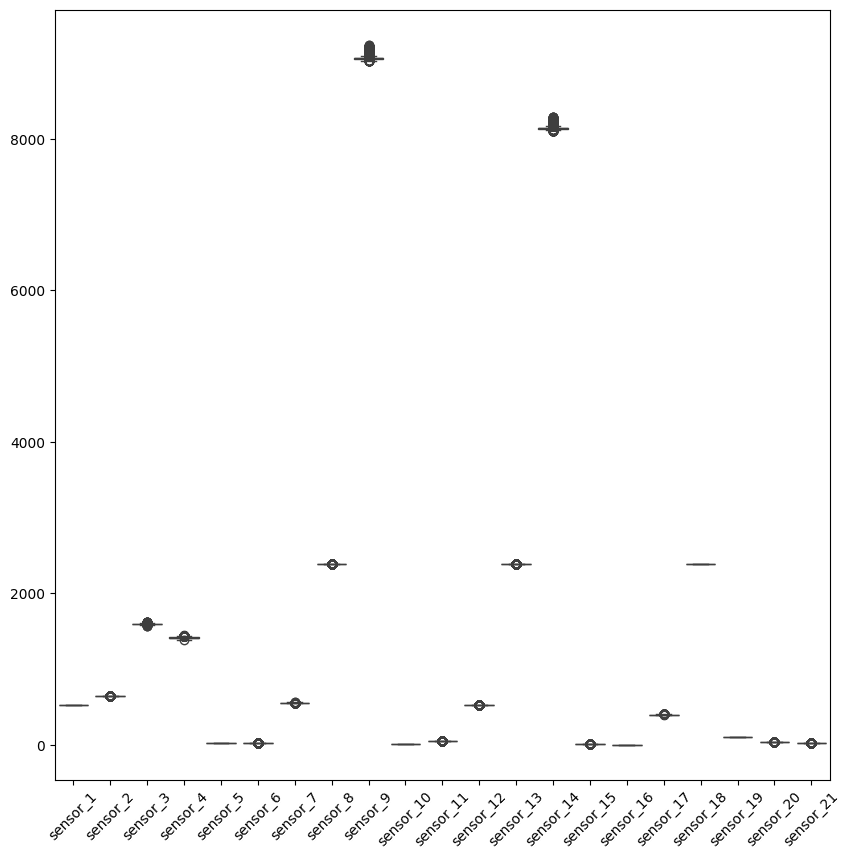

In [13]:
plt.figure(figsize=(10,10))
sns.boxplot(data=train_df.iloc[:, 5:26])
plt.xticks(rotation=45)
plt.show()

In [14]:
print(train_df['sensor_6'].value_counts())

sensor_6
21.61    20225
21.60      406
Name: count, dtype: int64


In [15]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0


In [16]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ?
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Fan.PR[-],LPC.TR[-],HPC.TR[-],OPR[-],Wf[pph],Wa36[lbm/s],W24[lbm/s],W15[lbm/s],W2[lbm/s],WfP3C[pph/psi]
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,1.478112,1.237434,2.476863,37.917921,24763.2002,229.288891,291.767891,2456.539756,2748.307647,47.47
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,1.478112,1.238070,2.478891,37.876197,24803.0772,229.658122,292.081722,2462.774665,2754.856388,47.49
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,1.478112,1.238456,2.472157,37.911081,24694.7934,228.655494,290.949694,2449.156338,2740.106032,47.27
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,1.478112,1.238456,2.464062,37.924077,24642.3918,228.170294,290.424194,2430.327744,2720.751938,47.13
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,1.478112,1.238495,2.464078,37.893297,24689.1432,228.603178,290.907578,2452.176336,2743.083914,47.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,1.478112,1.240654,2.483302,37.717510,24971.8843,231.221151,292.684651,2486.531720,2779.216371,48.07
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,1.478112,1.240750,2.493241,37.678523,24965.4272,231.161363,292.620763,2491.343914,2783.964677,48.04
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,1.478112,1.240519,2.490535,37.683995,25007.2809,231.548897,292.922197,2508.761450,2801.683648,48.09
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,1.478112,1.240153,2.495624,37.666211,25146.8313,232.841031,294.195031,2512.101946,2806.296977,48.39


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   Alt[kft]        20631 non-null  float64
 3   Mn[-]           20631 non-null  float64
 4   TLA[deg]        20631 non-null  float64
 5   T2[R]           20631 non-null  float64
 6   T24[R]          20631 non-null  float64
 7   T30[R]          20631 non-null  float64
 8   T50[R]          20631 non-null  float64
 9   P2[psi]         20631 non-null  float64
 10  P15[psi]        20631 non-null  float64
 11  P30[psi]        20631 non-null  float64
 12  Nf[rpm]         20631 non-null  float64
 13  Nc[rpm]         20631 non-null  float64
 14  epr[-]          20631 non-null  float64
 15  phi[pph/psi]    20631 non-null  float64
 16  Ps30[psi]       20631 non-null  float64
 17  NRf[rpm]        20631 non-null 

In [18]:
train_df.describe()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Fan.PR[-],LPC.TR[-],HPC.TR[-],OPR[-],Wf[pph],Wa36[lbm/s],W24[lbm/s],W15[lbm/s],W2[lbm/s],WfP3C[pph/psi]
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,1.478099,1.239094,2.474822,37.850049,24788.438631,229.522580,291.628556,2461.991478,2753.620034,47.541168
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.000095,0.000964,0.008518,0.060540,111.059960,1.028333,0.833983,16.485532,17.214334,0.267087
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,1.477428,1.236258,2.444552,37.609439,24479.455000,226.661620,289.025794,2416.311089,2706.562154,46.850000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,1.478112,1.238408,2.468961,37.811902,24708.848550,228.785635,291.039650,2450.012828,2741.074169,47.350000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,1.478112,1.239015,2.474444,37.854993,24778.261600,229.428348,291.570154,2460.306009,2751.852633,47.510000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,1.478112,1.239709,2.480312,37.893981,24857.587350,230.162846,292.159548,2472.064958,2764.163029,47.700000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,1.478112,1.242659,2.513266,38.034200,25233.796400,233.646263,294.997263,2524.409578,2819.406841,48.530000


In [19]:
train_df.isnull().sum()

unit_number       0
time_in_cycles    0
Alt[kft]          0
Mn[-]             0
TLA[deg]          0
T2[R]             0
T24[R]            0
T30[R]            0
T50[R]            0
P2[psi]           0
P15[psi]          0
P30[psi]          0
Nf[rpm]           0
Nc[rpm]           0
epr[-]            0
phi[pph/psi]      0
Ps30[psi]         0
NRf[rpm]          0
NRc[rpm]          0
BPR[-]            0
farB[-]           0
htBleed[]         0
Nf_dmd[rpm]       0
PCNfR_dmd[Pct]    0
W31[lbm/s]        0
W32[lbm/s]        0
condition         0
P50[psi]          0
Fan.PR[-]         0
LPC.TR[-]         0
HPC.TR[-]         0
OPR[-]            0
Wf[pph]           0
Wa36[lbm/s]       0
W24[lbm/s]        0
W15[lbm/s]        0
W2[lbm/s]         0
WfP3C[pph/psi]    0
dtype: int64

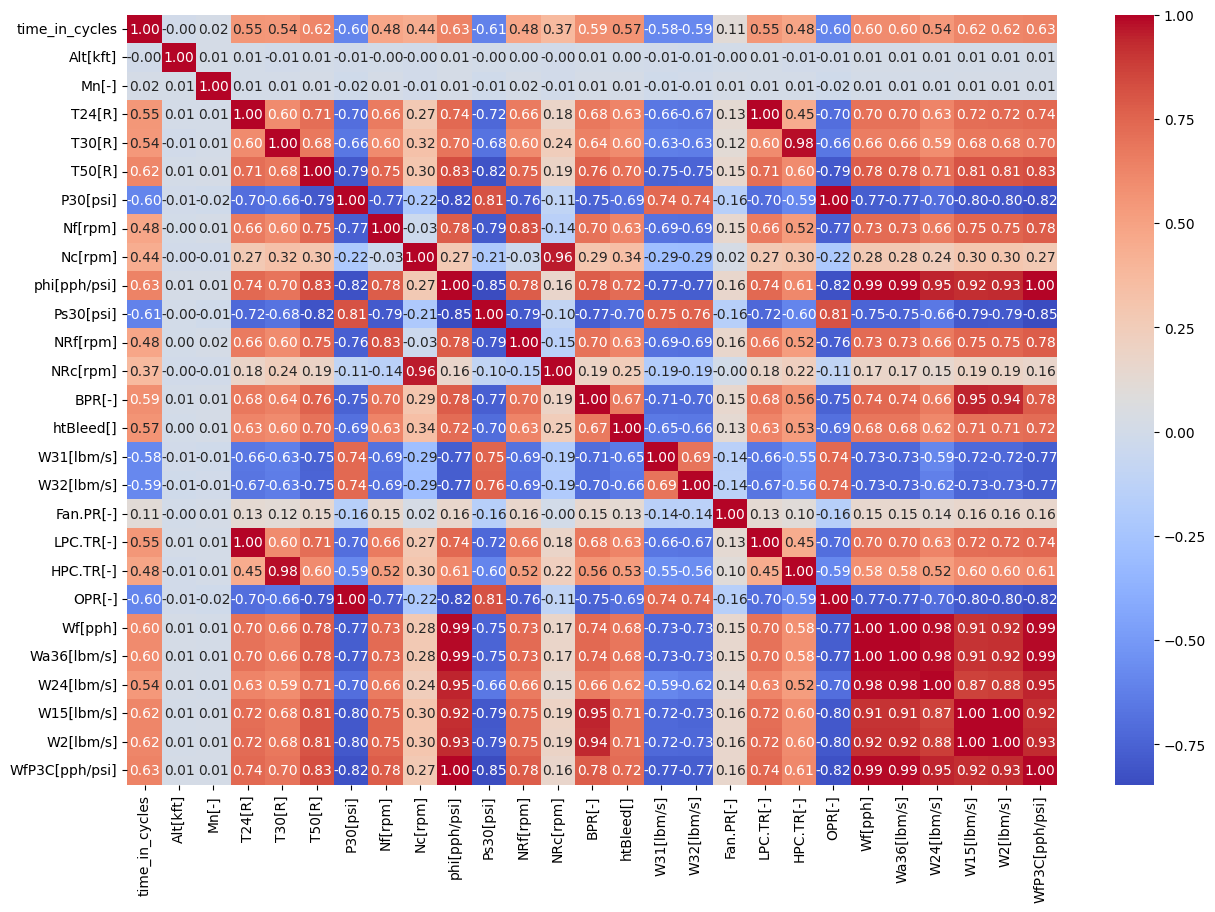

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

drop_cols = [
    'unit_number', 
    'op_setting_3', 'TLA[deg]', 
    'sensor_1', 'T2[R]', 
    'sensor_5', 'P2[psi]', 
    'sensor_6', 'P15[psi]', 
    'sensor_10', 'epr[-]', 
    'sensor_16', 'farB[-]', 
    'sensor_18', 'Nf_dmd[rpm]', 
    'sensor_19', 'PCNfR_dmd[Pct]', 
    'P50[psi]', 'condition' # 이 컬럼이 문자열이므로 반드시 제외해야 오류가 나지 않습니다.
] 

df = train_df.drop(columns=drop_cols + ['RUL'], errors='ignore') # 테스트 대상 features

plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [31]:
# 1. 제거할 컬럼 리스트 (앞서 설명한 대로 상세히 기술)
drop_cols = [
    'unit_number', 'op_setting_3', 'TLA[deg]', 
    'sensor_1', 'T2[R]', 'sensor_5', 'P2[psi]', 
    'sensor_6', 'P15[psi]', 'sensor_10', 'epr[-]', 
    'sensor_16', 'farB[-]', 'sensor_18', 'Nf_dmd[rpm]', 
    'sensor_19', 'PCNfR_dmd[Pct]', 'condition'
]

# 2. X_train 준비
X_train = train_df.drop(columns=drop_cols, errors='ignore')

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(X_train.median(), inplace=True)

# 3. scaler 학습 (X_train의 컬럼 순서와 종류가 기록됨)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. X_test 준비 (X_train과 동일한 컬럼만 선택하도록 강제)
# test_with_rul에서 X_train에 있는 컬럼들만 이름 기반으로 추출합니다.
X_test = test_with_rul.reindex(columns=X_train.columns)

# 5. transform 수행
X_test_scaled = scaler.transform(X_test)

print("Scaled Train Shape:", X_train_scaled.shape)
print("Scaled Test Shape:", X_test_scaled.shape)

Scaled Train Shape: (20631, 28)
Scaled Test Shape: (100, 28)


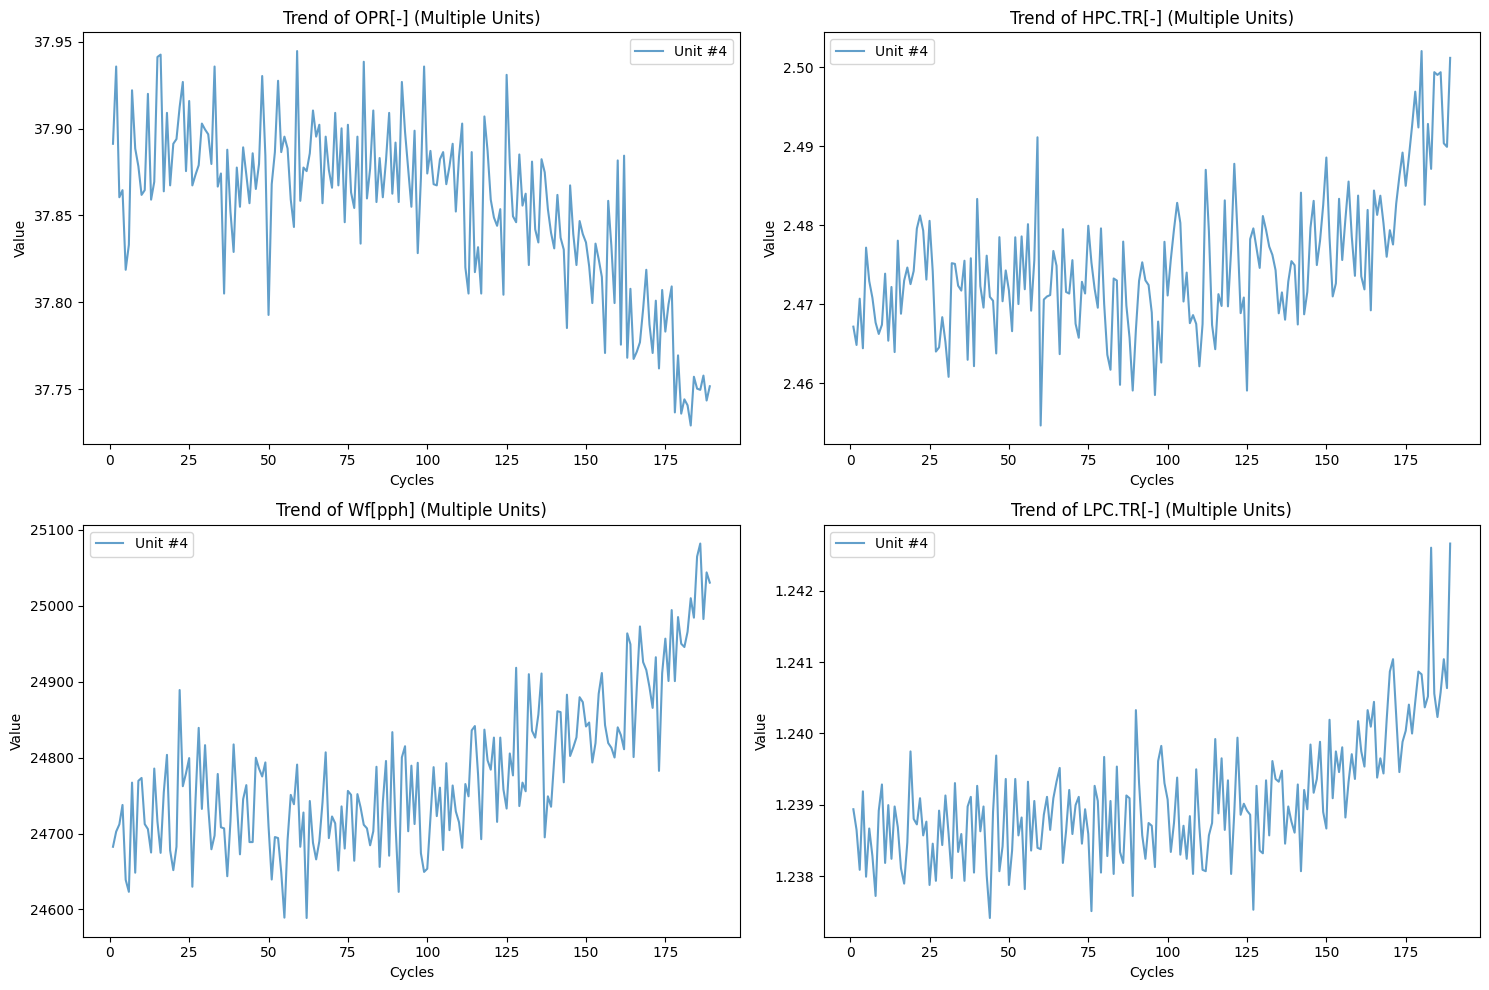

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import random

# 1. 시각화할 피처 선택
features_to_plot = ['OPR[-]', 'HPC.TR[-]', 'Wf[pph]', 'LPC.TR[-]']

# 2. 랜덤하게 1개의 엔진 번호 선택
random_units = random.sample(train_df['unit_number'].unique().tolist(), 1)

plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    
    # 선택된 엔진에 대해 그래프 그리기
    for unit in random_units:
        unit_data = train_df[train_df['unit_number'] == unit]
        plt.plot(unit_data['time_in_cycles'], unit_data[col], label=f'Unit #{unit}', alpha=0.7)
    
    plt.title(f'Trend of {col} (Multiple Units)')
    plt.xlabel('Cycles')
    plt.ylabel('Value')
    plt.legend() # 어떤 선이 어떤 엔진인지 표시

plt.tight_layout()
plt.show()

In [44]:
# 1. RUL 데이터 불러오기 (이미 불러오셨다면 이 부분은 건너뛰셔도 됩니다)
# rul_df = pd.read_csv(rul_path, sep=" ", header=None, names=['RUL'])
# rul_df['unit_number'] = rul_df.index + 1

# 2. train_df에 RUL 정보 결합 (학습 데이터는 시계열이므로 각 시점별 RUL 계산이 필요할 수 있습니다)
# 하지만 사용자분께서 외부 파일에서 불러오길 원하시므로, 
# 만약 train_df용 RUL 파일이 따로 있다면 아래처럼 merge 하시면 됩니다.

# 예시: train_df에 RUL이 포함되도록 rul_df와 결합
# (주의: rul_df가 마지막 시점의 RUL만 담고 있다면, 전체 train_df에 병합할 때는 
#  각 유닛의 최대 사이클 정보를 활용해 역산하는 방식이 일반적입니다.)

# 만약 train_df에 이미 RUL 정보를 넣는 과정이 누락되었다면 아래처럼 확인해 보세요:
if 'RUL' not in train_df.columns:
    # rul_df를 사용하여 train_df에 RUL을 매핑하는 예시
    # (학습 데이터의 경우 보통 파일에 RUL이 한 컬럼으로 존재하거나 직접 계산합니다.
    #  만약 외부 파일에서 불러온 rul_df가 학습 데이터용 데이터프레임이라면 다음을 실행하세요.)
    train_df = pd.merge(train_df, rul_df, on='unit_number', how='left')

# 3. 이제 상관관계 계산
numeric_df = train_df.select_dtypes(include=['number'])
if 'RUL' in numeric_df.columns:
    correlation = numeric_df.corr()['RUL'].sort_values()
    print(correlation)
else:
    print("여전히 'RUL' 컬럼이 train_df에 없습니다. 컬럼명을 확인해 주세요:", train_df.columns)

time_in_cycles   -0.736241
phi[pph/psi]     -0.696228
WfP3C[pph/psi]   -0.696228
W2[lbm/s]        -0.681120
W15[lbm/s]       -0.681120
T50[R]           -0.678948
Wa36[lbm/s]      -0.660278
Wf[pph]          -0.660278
BPR[-]           -0.642667
T24[R]           -0.606484
LPC.TR[-]        -0.606484
htBleed[]        -0.606154
W24[lbm/s]       -0.595226
T30[R]           -0.584520
Nf[rpm]          -0.563968
NRf[rpm]         -0.562569
HPC.TR[-]        -0.517380
Nc[rpm]          -0.390102
NRc[rpm]         -0.306769
Fan.PR[-]        -0.128348
P15[psi]         -0.128348
Alt[kft]         -0.003198
Mn[-]            -0.001948
unit_number       0.078753
W31[lbm/s]        0.629428
W32[lbm/s]        0.635662
P30[psi]          0.657223
OPR[-]            0.657223
Ps30[psi]         0.671983
RUL               1.000000
TLA[deg]               NaN
T2[R]                  NaN
P2[psi]                NaN
epr[-]                 NaN
farB[-]                NaN
Nf_dmd[rpm]            NaN
PCNfR_dmd[Pct]         NaN
P

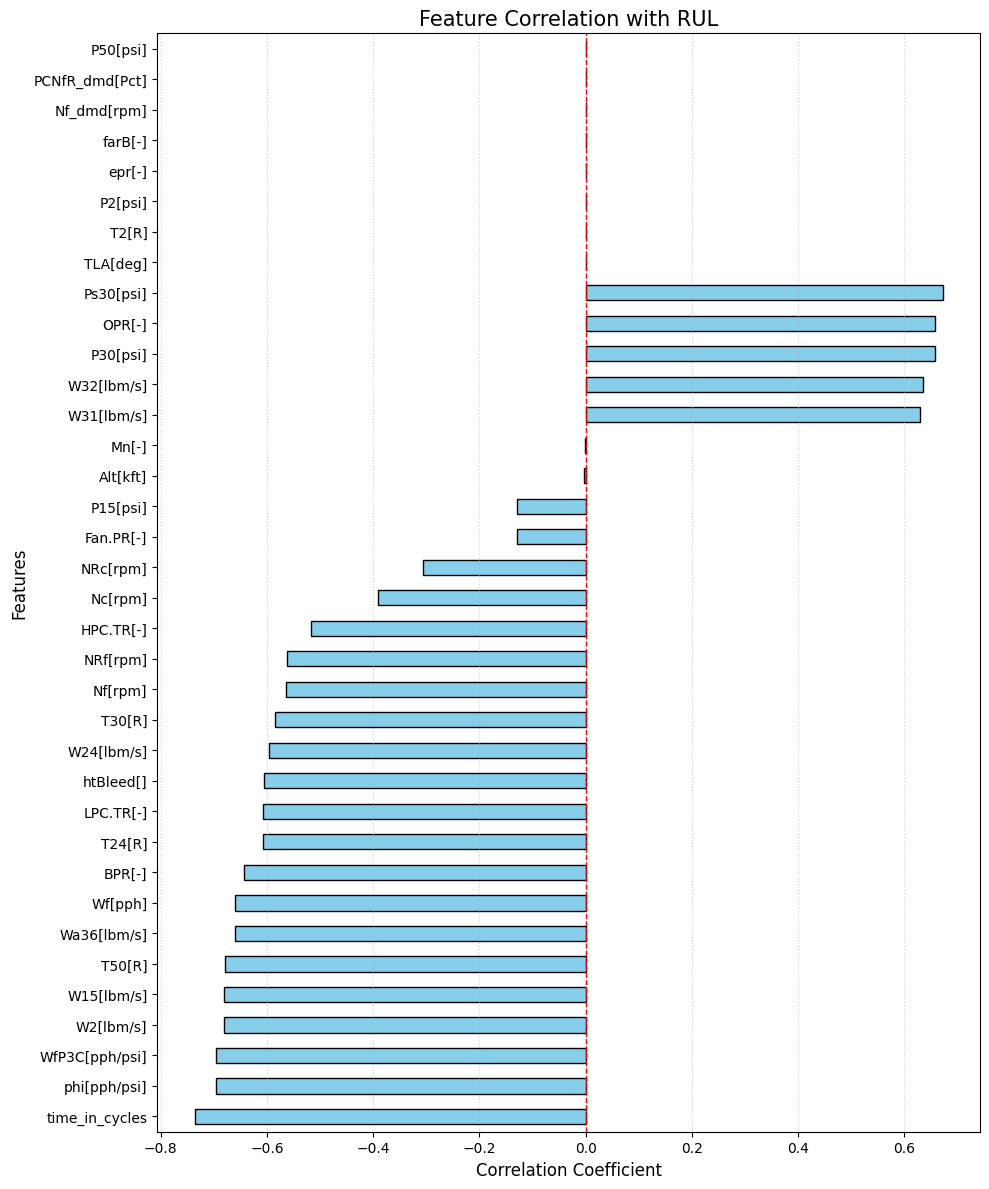

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 계산할 데이터만 준비 (condition 컬럼 등 문자열 제외)
# 숫자가 아닌 데이터는 상관관계 계산이 안 되므로 미리 제거합니다.
df_for_corr = train_df.select_dtypes(include=['number'])

# 만약 'unit_number'처럼 분석에 의미 없는 숫자 컬럼도 빼고 싶다면 아래처럼 추가로 drop 하세요.
df_for_corr = df_for_corr.drop(columns=['unit_number'], errors='ignore')

# 2. RUL과의 상관관계 계산 및 정렬
if 'RUL' in df_for_corr.columns:
    correlation = df_for_corr.corr()['RUL'].sort_values()

    # 3. 시각화 (가로 막대 그래프)
    plt.figure(figsize=(10, 12))
    
    # RUL 자기 자신은 상관관계가 1이므로 그래프에서 제외하고 그립니다.
    correlation.drop('RUL').plot(kind='barh', color='skyblue', edgecolor='black')
    
    plt.title('Feature Correlation with RUL', fontsize=15)
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1) # 0 기준선 추가
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'RUL' 컬럼이 데이터프레임에 없습니다. 앞 단계의 merge 코드를 확인해 주세요!")